# TICE Training Notebook: Planner Teacher -> SFT -> GRPO

This notebook is a final, end-to-end demo pipeline for TICE.

It does four things:
1. builds a strong scripted teacher using short-horizon lookahead over the 16 actions
2. generates supervised data from that teacher
3. fine-tunes a compact text policy with Unsloth + TRL SFT
4. improves it with GRPO on a frozen TICE state distribution, then evaluates back in the real environment

The goal is to show the full loop from environment rollouts → training data → trained policy → evaluation plots, in one place.


## 0. Upload the tice repo

Get the repository into the runtime so the environment code and notebooks can be imported and executed.

In [2]:

#!unzip tice.zip

Archive:  tice.zip
   creating: tice/
  inflating: tice/.env               
  inflating: tice/02_eval_harness.ipynb  
  inflating: tice/03_prompt_action_format.ipynb  
  inflating: tice/04_tice_sft_grpo_training.ipynb  
  inflating: tice/client.py          
   creating: tice/core/
  inflating: tice/core/b_cell.py     
  inflating: tice/core/reward.py     
  inflating: tice/core/tumor.py      
  inflating: tice/core/t_cell.py     
  inflating: tice/core/__init__.py   
   creating: tice/core/__pycache__/
  inflating: tice/core/__pycache__/b_cell.cpython-310.pyc  
  inflating: tice/core/__pycache__/reward.cpython-310.pyc  
  inflating: tice/core/__pycache__/tumor.cpython-310.pyc  
  inflating: tice/core/__pycache__/t_cell.cpython-310.pyc  
  inflating: tice/core/__pycache__/__init__.cpython-310.pyc  
   creating: tice/data/
  inflating: tice/data/sampler.py    
  inflating: tice/data/tcga_params.py  
  inflating: tice/data/__init__.py   
   creating: tice/data/__pycache__/
  inflating: ti

In [3]:
# %pip install -e /content/tice

Obtaining file:///content/tice
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.6/174.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.3/152.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 15.6 MB/s eta 0:00:00
  Building editable for tice (pyproject

## 1. Setup

Install the training dependencies and import the core TICE environment + training utilities used throughout the notebook.

In [1]:
# Colab sometimes needs this for UTF-8 handling with text generation.
import locale
locale.getpreferredencoding = lambda: 'UTF-8'

In [10]:
# If needed, uncomment and adjust local path.
# %pip install -e /content/tice

%pip install -q -U unsloth trl transformers datasets accelerate peft bitsandbytes wandb seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 4.6 MB/s eta 0:00:00


In [4]:
import copy
import json
import os
import random
from typing import Dict, List, Tuple
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from tqdm.auto import tqdm
from transformers import TextStreamer

from tice.models import B_CELL_ACTIONS, T_CELL_ACTIONS, TICEAction
from tice.server.tice_environment import TICEEnvironment

from unsloth import FastLanguageModel, is_bfloat16_supported
from trl import GRPOConfig, GRPOTrainer, SFTConfig, SFTTrainer

## 2. Optional Weights & Biases

Optional experiment logging. Turn this on if you want tracked metrics and artifacts across runs.

In [ ]:
USE_WANDB = False

if USE_WANDB:
    import wandb
    wandb.login()
    wandb.init(project='tice-sft-grpo-demo', name='planner-teacher-run')

## 3. Global Config

Set seeds, episode sampling parameters, training hyperparameters, and local artifact paths for caching and exports.

In [5]:
GLOBAL_SEED = 42
ARCHETYPES = ['immune_hot', 'immune_cold', 'high_mutation']
DIFFICULTIES = ['easy', 'medium', 'hard']

MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
MAX_SEQ_LENGTH = 512
LOAD_IN_4BIT = True
LORA_RANK = 16

TRAIN_EPISODES_FOR_DATA = 180
EVAL_SEEDS_PER_COMBO = 3
MAX_STEPS_PER_EPISODE = 50
TEACHER_EPSILON = 0.15
PLANNER_HORIZON = 3
PLANNER_GAMMA = 0.95

SFT_MAX_STEPS = 120
GRPO_MAX_STEPS = 200
GRPO_NUM_GENERATIONS = 2

BASE_MODEL_EVAL_ENABLED = False
SFT_EVAL_ENABLED = False
GRPO_EVAL_ENABLED = False


SAFE_DEFAULT_JOINT_ACTION = 'B=MAINTAIN|T=ATTACK_LOW'

# saving data
RUN_NAME = 'tice_demo_run'
BASE_ARTIFACT_DIR = os.getenv('TICE_ARTIFACT_DIR', '/content/tice_runs')
RUN_DIR = Path(BASE_ARTIFACT_DIR) / RUN_NAME
EVAL_DIR = RUN_DIR / 'eval_cache'
DATA_DIR = RUN_DIR / 'data_cache'
CHECKPOINT_DIR = RUN_DIR / 'checkpoints'
EXPORT_DIR = RUN_DIR / 'exports'

for path in [RUN_DIR, EVAL_DIR, DATA_DIR, CHECKPOINT_DIR, EXPORT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('Artifacts will be stored in:', RUN_DIR)
print('Tip: in Colab you can set TICE_ARTIFACT_DIR to a Drive path before running this cell.')


def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_global_seed(GLOBAL_SEED)

Artifacts will be stored in: /content/tice_runs/tice_demo_run
Tip: in Colab you can set TICE_ARTIFACT_DIR to a Drive path before running this cell.


## 4. Canonical Action Language

Define the 16 joint actions and the mapping between string actions and `(B action, T action)` pairs.

In [6]:
JOINT_ACTIONS = [f'B={b}|T={t}' for b in B_CELL_ACTIONS for t in T_CELL_ACTIONS]

ACTION_TO_PAIR = {
    action: {
        'b_cell_action': action.split('|')[0].replace('B=', ''),
        't_cell_action': action.split('|')[1].replace('T=', ''),
    }
    for action in JOINT_ACTIONS
}

PAIR_TO_ACTION = {
    (value['b_cell_action'], value['t_cell_action']): key
    for key, value in ACTION_TO_PAIR.items()
}

print('Total joint actions:', len(JOINT_ACTIONS))
JOINT_ACTIONS

Total joint actions: 16


['B=INCREASE_HIGH|T=ATTACK_HIGH',
 'B=INCREASE_HIGH|T=ATTACK_MEDIUM',
 'B=INCREASE_HIGH|T=ATTACK_LOW',
 'B=INCREASE_HIGH|T=REST',
 'B=INCREASE_LOW|T=ATTACK_HIGH',
 'B=INCREASE_LOW|T=ATTACK_MEDIUM',
 'B=INCREASE_LOW|T=ATTACK_LOW',
 'B=INCREASE_LOW|T=REST',
 'B=MAINTAIN|T=ATTACK_HIGH',
 'B=MAINTAIN|T=ATTACK_MEDIUM',
 'B=MAINTAIN|T=ATTACK_LOW',
 'B=MAINTAIN|T=REST',
 'B=REDUCE|T=ATTACK_HIGH',
 'B=REDUCE|T=ATTACK_MEDIUM',
 'B=REDUCE|T=ATTACK_LOW',
 'B=REDUCE|T=REST']

## 5. Prompt Builder and Parser

Build the observation prompt format used for both teacher labeling and model training, and define a strict parser for model outputs.

In [7]:
SYSTEM_PROMPT = f"""You are controlling a tumor immune environment.

Choose exactly one action from this list:
{', '.join(JOINT_ACTIONS)}

Return exactly one action string and nothing else.
Example:
B=MAINTAIN|T=ATTACK_LOW
""".strip()


def build_user_prompt(obs) -> str:
    return f"""Observation:
archetype={obs.archetype}
difficulty={obs.difficulty}
timestep={obs.timestep}
episode_phase={obs.episode_phase}
tumor_trend={obs.tumor_trend}
detection_signal={obs.detection_signal}
t_cell_effectiveness={obs.t_cell_effectiveness}
resource_level={obs.resource_level}
b_cell_fatigue={obs.b_cell_fatigue}
t_cell_fatigue={obs.t_cell_fatigue}
recent_outcome={obs.recent_outcome}
feedback={obs.feedback}

Choose the next action.
Return exactly one action string.
""".strip()


def build_full_prompt(obs) -> str:
    return SYSTEM_PROMPT + '\n\n' + build_user_prompt(obs)


def canonicalize_joint_action(text: str) -> Tuple[str, bool]:
    if not isinstance(text, str):
        return SAFE_DEFAULT_JOINT_ACTION, False

    cleaned = text.strip()
    if cleaned in ACTION_TO_PAIR:
        return cleaned, True

    cleaned = cleaned.replace('```', '').strip()
    normalized = cleaned.upper().replace(' ', '').replace('-', '_')

    for candidate in JOINT_ACTIONS:
        if normalized == candidate.upper().replace(' ', ''):
            return candidate, True

    return SAFE_DEFAULT_JOINT_ACTION, False


def parse_model_output(text: str) -> Dict:
    action, valid = canonicalize_joint_action(text)
    pair = ACTION_TO_PAIR[action]
    return {
        'joint_action': action,
        'b_cell_action': pair['b_cell_action'],
        't_cell_action': pair['t_cell_action'],
        'valid': valid,
        'raw_output': text,
    }

## 6. Evaluation Harness

Define the evaluation suite, episode runner, and summary metrics used to compare policies across archetypes and difficulty settings.

In [8]:
def make_eval_suite(seeds_per_combo: int = 10, start_seed: int = 3000) -> List[Dict]:
    suite = []
    seed = start_seed
    for archetype in ARCHETYPES:
        for difficulty in DIFFICULTIES:
            for _ in range(seeds_per_combo):
                suite.append({
                    'archetype': archetype,
                    'difficulty': difficulty,
                    'seed': seed,
                })
                seed += 1
    return suite


EVAL_MAIN = make_eval_suite(seeds_per_combo=EVAL_SEEDS_PER_COMBO)
print('Eval episodes:', len(EVAL_MAIN))

Eval episodes: 27


In [9]:
def random_policy(obs, env=None):
    return (
        random.choice(B_CELL_ACTIONS),
        random.choice(T_CELL_ACTIONS),
        {'policy_type': 'random'},
    )


def run_single_episode(policy_fn, archetype: str, difficulty: str, seed: int, max_steps: int = MAX_STEPS_PER_EPISODE):
    set_global_seed(seed)
    env = TICEEnvironment(archetype=archetype, difficulty=difficulty, max_steps=max_steps)
    obs = env.reset()

    total_reward = 0.0
    invalid_actions = 0
    steps = 0

    while not obs.done and steps < max_steps:
        b_action, t_action, meta = policy_fn(obs, env)
        if b_action not in B_CELL_ACTIONS or t_action not in T_CELL_ACTIONS:
            invalid_actions += 1
            b_action = ACTION_TO_PAIR[SAFE_DEFAULT_JOINT_ACTION]['b_cell_action']
            t_action = ACTION_TO_PAIR[SAFE_DEFAULT_JOINT_ACTION]['t_cell_action']

        obs = env.step(TICEAction(b_cell_action=b_action, t_cell_action=t_action))
        total_reward += float(obs.reward)
        steps += 1

    feedback = obs.feedback
    return {
        'seed': seed,
        'archetype': archetype,
        'difficulty': difficulty,
        'return': float(total_reward),
        'won': int('VICTORY' in feedback),
        'lost': int('DEFEAT' in feedback),
        'timeout': int('TIMEOUT' in feedback),
        'steps': int(steps),
        'invalid_action_rate': float(invalid_actions / max(steps, 1)),
        'final_tumor_size': float(env.tumor.tumor_size),
    }


def evaluate_policy(policy_fn, suite: List[Dict], policy_name: str, cache_path: str | None = None, save_every: int = 5) -> pd.DataFrame:
    rows = []
    completed = set()

    if cache_path and os.path.exists(cache_path):
        cached_df = pd.read_csv(cache_path)
        rows = cached_df.to_dict('records')
        completed = {
            (row['archetype'], row['difficulty'], int(row['seed']))
            for row in rows
        }
        print(f'Loaded {len(rows)} cached rows from {cache_path}')

    pending = [
        item for item in suite
        if (item['archetype'], item['difficulty'], int(item['seed'])) not in completed
    ]

    progress = tqdm(pending, desc=f'eval:{policy_name}', total=len(pending))
    for idx, item in enumerate(progress, start=1):
        result = run_single_episode(policy_fn, item['archetype'], item['difficulty'], item['seed'])
        result['policy'] = policy_name
        rows.append(result)
        progress.set_postfix({'last_return': round(result['return'], 3), 'wins': sum(r['won'] for r in rows)})

        if cache_path and (idx % save_every == 0 or idx == len(pending)):
            pd.DataFrame(rows).to_csv(cache_path, index=False)

    df = pd.DataFrame(rows)
    if cache_path:
        df.to_csv(cache_path, index=False)
    return df


def summarize_episodes(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby('policy', as_index=False)
        .agg(
            n_episodes=('policy', 'size'),
            avg_return=('return', 'mean'),
            std_return=('return', 'std'),
            win_rate=('won', 'mean'),
            loss_rate=('lost', 'mean'),
            timeout_rate=('timeout', 'mean'),
            avg_steps=('steps', 'mean'),
            avg_final_tumor_size=('final_tumor_size', 'mean'),
            avg_invalid_action_rate=('invalid_action_rate', 'mean'),
        )
    )
    for col in ['win_rate', 'loss_rate', 'timeout_rate', 'avg_invalid_action_rate']:
        summary[col] *= 100.0
    return summary.sort_values('avg_return', ascending=False).reset_index(drop=True)

## 7. Short-Horizon Planner Teacher

This teacher evaluates all 16 actions with discounted lookahead over a short planning horizon.

That is important here because one-step rewards are too myopic and can prefer low-effort actions that still lose quickly.

In [ ]:
def _rollout_value(env: TICEEnvironment, depth: int, gamma: float) -> float:
    if depth <= 0 or env.tumor.is_eradicated() or env.tumor.is_escaped() or env.tumor.timestep >= env.max_steps:
        return 0.0

    saved_rng = np.random.get_state()
    best_value = -1e18

    for joint_action in JOINT_ACTIONS:
        np.random.set_state(saved_rng)
        env_copy = copy.deepcopy(env)
        pair = ACTION_TO_PAIR[joint_action]
        next_obs = env_copy.step(
            TICEAction(
                b_cell_action=pair['b_cell_action'],
                t_cell_action=pair['t_cell_action'],
            )
        )
        reward = float(next_obs.reward)
        future_value = _rollout_value(env_copy, depth - 1, gamma)
        total_value = reward + (gamma * future_value)
        if total_value > best_value:
            best_value = total_value

    np.random.set_state(saved_rng)
    return float(best_value)


def compute_reward_table(env: TICEEnvironment, horizon: int = PLANNER_HORIZON, gamma: float = PLANNER_GAMMA) -> Dict[str, float]:
    saved_rng = np.random.get_state()
    reward_table = {}

    for joint_action in JOINT_ACTIONS:
        np.random.set_state(saved_rng)
        env_copy = copy.deepcopy(env)
        pair = ACTION_TO_PAIR[joint_action]
        next_obs = env_copy.step(
            TICEAction(
                b_cell_action=pair['b_cell_action'],
                t_cell_action=pair['t_cell_action'],
            )
        )
        immediate_reward = float(next_obs.reward)
        future_value = _rollout_value(env_copy, horizon - 1, gamma)
        reward_table[joint_action] = immediate_reward + (gamma * future_value)

    np.random.set_state(saved_rng)
    return reward_table


def planner_best_joint_action(env: TICEEnvironment, horizon: int = PLANNER_HORIZON, gamma: float = PLANNER_GAMMA) -> Tuple[str, Dict[str, float]]:
    reward_table = compute_reward_table(env, horizon=horizon, gamma=gamma)
    best_action = max(reward_table.items(), key=lambda kv: kv[1])[0]
    return best_action, reward_table


def planner_policy(obs, env=None):
    best_action, reward_table = planner_best_joint_action(env)
    pair = ACTION_TO_PAIR[best_action]
    return pair['b_cell_action'], pair['t_cell_action'], {
        'policy_type': 'planner',
        'joint_action': best_action,
        'reward_table': reward_table,
    }

## 8. Benchmark Random vs Planner

Establish baseline performance for a random policy and the planner teacher on the same evaluation suite.

In [ ]:
random_eval_path = EVAL_DIR / 'random_eval.csv'
planner_eval_path = EVAL_DIR / 'planner_teacher_eval.csv'

random_eval = evaluate_policy(random_policy, EVAL_MAIN, policy_name='random', cache_path=str(random_eval_path))
planner_eval = evaluate_policy(planner_policy, EVAL_MAIN, policy_name='planner_teacher', cache_path=str(planner_eval_path))

baseline_eval = pd.concat([random_eval, planner_eval], ignore_index=True)
display(summarize_episodes(baseline_eval))

## 9. Planner Dataset Generation

We collect prompts from real TICE rollouts. The teacher labels each state with the best short-horizon action, and we also store the full reward table for GRPO.

In [ ]:
TRAIN_SUITE = make_eval_suite(seeds_per_combo=TRAIN_EPISODES_FOR_DATA // 9, start_seed=5000)
print('Training rollout episodes:', len(TRAIN_SUITE))

In [ ]:
def rollout_teacher_dataset(suite: List[Dict], epsilon: float = TEACHER_EPSILON, cache_path: str | None = None, save_every: int = 25) -> pd.DataFrame:
    rows = []
    completed = set()

    if cache_path and os.path.exists(cache_path):
        cached_df = pd.read_csv(cache_path)
        rows = cached_df.to_dict('records')
        completed = {
            (int(row['seed']), row['archetype'], row['difficulty'], int(row['timestep']))
            for row in rows
        }
        print(f'Loaded {len(rows)} cached planner rows from {cache_path}')

    episode_progress = tqdm(suite, desc='planner_dataset', total=len(suite))
    new_rows = 0
    for item in episode_progress:
        set_global_seed(item['seed'])
        env = TICEEnvironment(
            archetype=item['archetype'],
            difficulty=item['difficulty'],
            max_steps=MAX_STEPS_PER_EPISODE,
        )
        obs = env.reset()
        step_idx = 0

        while not obs.done and step_idx < MAX_STEPS_PER_EPISODE:
            key = (item['seed'], item['archetype'], item['difficulty'], int(obs.timestep))
            if key in completed:
                best_joint_action, _ = planner_best_joint_action(env)
                chosen_joint_action = best_joint_action if random.random() >= epsilon else random.choice(JOINT_ACTIONS)
                pair = ACTION_TO_PAIR[chosen_joint_action]
                obs = env.step(
                    TICEAction(
                        b_cell_action=pair['b_cell_action'],
                        t_cell_action=pair['t_cell_action'],
                    )
                )
                step_idx += 1
                continue

            prompt = build_full_prompt(obs)
            best_joint_action, reward_table = planner_best_joint_action(env)

            rows.append({
                'prompt': prompt,
                'completion': best_joint_action,
                'reward_table_json': json.dumps(reward_table),
                'seed': item['seed'],
                'archetype': item['archetype'],
                'difficulty': item['difficulty'],
                'timestep': int(obs.timestep),
            })
            new_rows += 1
            episode_progress.set_postfix({'rows': len(rows), 'new_rows': new_rows, 'seed': item['seed']})

            if cache_path and new_rows % save_every == 0:
                pd.DataFrame(rows).to_csv(cache_path, index=False)

            if random.random() < epsilon:
                chosen_joint_action = random.choice(JOINT_ACTIONS)
            else:
                chosen_joint_action = best_joint_action

            pair = ACTION_TO_PAIR[chosen_joint_action]
            obs = env.step(
                TICEAction(
                    b_cell_action=pair['b_cell_action'],
                    t_cell_action=pair['t_cell_action'],
                )
            )
            step_idx += 1

    df = pd.DataFrame(rows)
    if cache_path:
        df.to_csv(cache_path, index=False)
    return df


planner_dataset_path = DATA_DIR / 'planner_dataset.csv'
planner_df = rollout_teacher_dataset(TRAIN_SUITE, cache_path=str(planner_dataset_path))
planner_df.head()

## 10. Train / Eval Dataset Prep

Shuffle and split teacher-labeled rollouts into train/val sets, and build the SFT and GRPO datasets used by TRL.

In [ ]:
planner_df = planner_df.sample(frac=1.0, random_state=GLOBAL_SEED).reset_index(drop=True)
split_idx = int(0.9 * len(planner_df))
train_df = planner_df.iloc[:split_idx].copy()
val_df = planner_df.iloc[split_idx:].copy()

print('Train rows:', len(train_df))
print('Val rows  :', len(val_df))

In [ ]:
def format_sft_row(prompt: str, completion: str) -> str:
    return prompt + '\n' + completion


train_sft_ds = Dataset.from_pandas(pd.DataFrame({
    'text': [format_sft_row(p, c) for p, c in zip(train_df['prompt'], train_df['completion'])]
})).shuffle(seed=GLOBAL_SEED)

val_sft_ds = Dataset.from_pandas(pd.DataFrame({
    'text': [format_sft_row(p, c) for p, c in zip(val_df['prompt'], val_df['completion'])]
}))

train_grpo_ds = Dataset.from_pandas(train_df[['prompt', 'reward_table_json']].reset_index(drop=True))
val_grpo_ds = Dataset.from_pandas(val_df[['prompt', 'reward_table_json']].reset_index(drop=True))


## 10B. Resume From Saved CSV Artifacts
If planner dataset is already present you can load it and directly go to step 11.

In [39]:
from pathlib import Path

RESUME_ROOT = Path('/content/final_save')
# Example for Drive:
# RESUME_ROOT = Path('/content/drive/MyDrive/final_save')

print('Loading resume artifacts from:', RESUME_ROOT)

planner_csv = RESUME_ROOT / 'planner_df.csv'
train_csv = RESUME_ROOT / 'train_df.csv'
val_csv = RESUME_ROOT / 'val_df.csv'
random_eval_csv = RESUME_ROOT / 'random_eval.csv'
planner_eval_csv = RESUME_ROOT / 'planner_eval.csv'
baseline_eval_csv = RESUME_ROOT / 'baseline_eval.csv'

if train_csv.exists() and val_csv.exists():
    train_df = pd.read_csv(train_csv)
    val_df = pd.read_csv(val_csv)
    if planner_csv.exists():
        planner_df = pd.read_csv(planner_csv)
    else:
        planner_df = pd.concat([train_df, val_df], ignore_index=True)
else:
    if not planner_csv.exists():
        raise FileNotFoundError(f'Missing planner dataset file: {planner_csv}')
    planner_df = pd.read_csv(planner_csv)
    planner_df = planner_df.sample(frac=1.0, random_state=GLOBAL_SEED).reset_index(drop=True)
    split_idx = int(0.9 * len(planner_df))
    train_df = planner_df.iloc[:split_idx].copy()
    val_df = planner_df.iloc[split_idx:].copy()

def format_sft_row(prompt: str, completion: str) -> str:
    return prompt + '\n' + completion

train_sft_ds = Dataset.from_pandas(pd.DataFrame({
    'text': [format_sft_row(p, c) for p, c in zip(train_df['prompt'], train_df['completion'])]
})).shuffle(seed=GLOBAL_SEED)

val_sft_ds = Dataset.from_pandas(pd.DataFrame({
    'text': [format_sft_row(p, c) for p, c in zip(val_df['prompt'], val_df['completion'])]
}))

train_grpo_ds = Dataset.from_pandas(train_df[['prompt', 'reward_table_json']].reset_index(drop=True))
val_grpo_ds = Dataset.from_pandas(val_df[['prompt', 'reward_table_json']].reset_index(drop=True))

if random_eval_csv.exists():
    random_eval = pd.read_csv(random_eval_csv).head(27)  # slice to 27
if planner_eval_csv.exists():
    sft_seeds = set(range(3000, 3027))
    planner_eval = pd.read_csv(planner_eval_csv)
    planner_eval = planner_eval[planner_eval['seed'].isin(sft_seeds)].reset_index(drop=True)

if baseline_eval_csv.exists():
    baseline_eval = pd.read_csv(baseline_eval_csv)

print('Loaded planner_df rows:', len(planner_df))
print('Loaded train_df rows  :', len(train_df))
print('Loaded val_df rows    :', len(val_df))
print('train_sft_ds rows     :', len(train_sft_ds))
print('val_sft_ds rows       :', len(val_sft_ds))
print('train_grpo_ds rows    :', len(train_grpo_ds))
print('val_grpo_ds rows      :', len(val_grpo_ds))

train_sft_ds[0]['text'][:1200]

Loading resume artifacts from: /content/final_save
Loaded planner_df rows: 6381
Loaded train_df rows  : 5742
Loaded val_df rows    : 639
train_sft_ds rows     : 5742
val_sft_ds rows       : 639
train_grpo_ds rows    : 5742
val_grpo_ds rows      : 639


'You are controlling a tumor immune environment.\n\nChoose exactly one action from this list:\nB=INCREASE_HIGH|T=ATTACK_HIGH, B=INCREASE_HIGH|T=ATTACK_MEDIUM, B=INCREASE_HIGH|T=ATTACK_LOW, B=INCREASE_HIGH|T=REST, B=INCREASE_LOW|T=ATTACK_HIGH, B=INCREASE_LOW|T=ATTACK_MEDIUM, B=INCREASE_LOW|T=ATTACK_LOW, B=INCREASE_LOW|T=REST, B=MAINTAIN|T=ATTACK_HIGH, B=MAINTAIN|T=ATTACK_MEDIUM, B=MAINTAIN|T=ATTACK_LOW, B=MAINTAIN|T=REST, B=REDUCE|T=ATTACK_HIGH, B=REDUCE|T=ATTACK_MEDIUM, B=REDUCE|T=ATTACK_LOW, B=REDUCE|T=REST\n\nReturn exactly one action string and nothing else.\nExample:\nB=MAINTAIN|T=ATTACK_LOW\n\nObservation:\narchetype=immune_hot\ndifficulty=medium\ntimestep=11\nepisode_phase=early\ntumor_trend=increasing\ndetection_signal=1.0\nt_cell_effectiveness=high\nresource_level=moderate\nb_cell_fatigue=0.54\nt_cell_fatigue=0.0\nrecent_outcome=no_effect\nfeedback=Tumor: 0.596 | Damage: 0.000 | Reward: -1.108\n\nChoose the next action.\nReturn exactly one action string.\nB=REDUCE|T=ATTACK_HIGH

## 11. Load Small Model with Unsloth

Load the base instruction-tuned model and attach a LoRA adapter configuration for efficient fine-tuning.

In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    # max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=LOAD_IN_4BIT,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    lora_alpha=LORA_RANK,
    lora_dropout=0,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=GLOBAL_SEED,
    # max_seq_length=MAX_SEQ_LENGTH,
)

tokenizer.padding_side = 'right'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


## 12. Generation Wrapper for Evaluation

Wrap model generation so it reliably emits exactly one joint action string that can be parsed and executed in the environment.

In [28]:
def generate_joint_action(model, tokenizer, prompt: str, max_new_tokens: int = 32) -> str:
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_new_tokens,
        max_length=None,        # ← explicitly unset to avoid the conflict
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    return tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

def make_model_policy(model, tokenizer):
    def _policy(obs, env=None):
        raw_output = generate_joint_action(model, tokenizer, build_full_prompt(obs))
        parsed = parse_model_output(raw_output)
        return parsed['b_cell_action'], parsed['t_cell_action'], parsed
    return _policy

## 13. Base Model Evaluation

Evaluate the untouched base model on the same suite to establish a true zero-shot baseline.

In [ ]:
if BASE_MODEL_EVAL_ENABLED:
    FastLanguageModel.for_inference(model)
    base_model_policy = make_model_policy(model, tokenizer)
    base_eval_path = EVAL_DIR / 'base_model_eval.csv'
    base_eval = evaluate_policy(base_model_policy, EVAL_MAIN, policy_name='base_model', cache_path=str(base_eval_path))
    display(summarize_episodes(pd.concat([random_eval, planner_eval, base_eval], ignore_index=True)))
else:
    base_eval = pd.DataFrame()
    print('Skipped base model evaluation for faster final run.')

In [ ]:
# Step 1: Fix format_sft_row
def format_sft_row(prompt: str, completion: str) -> str:
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return text + completion + tokenizer.eos_token

# Step 2: Rebuild datasets from existing CSVs
train_sft_ds = Dataset.from_pandas(pd.DataFrame({
    'text': [format_sft_row(p, c) for p, c in zip(train_df['prompt'], train_df['completion'])]
})).shuffle(seed=GLOBAL_SEED)

val_sft_ds = Dataset.from_pandas(pd.DataFrame({
    'text': [format_sft_row(p, c) for p, c in zip(val_df['prompt'], val_df['completion'])]
}))
'

## 14. Supervised Fine-Tuning (SFT)

Train the model to imitate the planner teacher by supervised learning on `(prompt → best action)` pairs.

In [ ]:
sft_args = SFTConfig(
    output_dir=str(CHECKPOINT_DIR / 'tice_sft_outputs1'),
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=10,
    max_steps=SFT_MAX_STEPS,
    logging_steps=10,
    save_steps=40,
    eval_steps=40,
    optim='adamw_8bit',
    learning_rate=2e-4,
    weight_decay=0.01,
    lr_scheduler_type='cosine',
    seed=GLOBAL_SEED,
    # report_to='wandb' if USE_WANDB else 'none',
    bf16=is_bfloat16_supported(),
    fp16=not is_bfloat16_supported(),
    # max_seq_length=MAX_SEQ_LENGTH,
)

sft_trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_sft_ds,
    eval_dataset=val_sft_ds,
    dataset_text_field='text',
    args=sft_args,
)

sft_trainer.train()

In [ ]:
import shutil

zip_path = "/content/checkpoint_sft"   # change this
folder_path = "/content/tice_runs/tice_demo_run/exports/tice_sft_adapter1"
shutil.make_archive(zip_path.replace('.zip',''), 'zip', folder_path)

'/content/checkpoint_sft.zip'

## 14B. Save SFT Adapter Checkpoint

Run this after SFT if you want the option to stop the session and resume later from the SFT checkpoint before starting GRPO.

In [ ]:
SFT_EXPORT_DIR = EXPORT_DIR / 'tice_sft_adapter1'
tokenizer.save_pretrained(SFT_EXPORT_DIR)
model.save_pretrained(SFT_EXPORT_DIR)
print('Saved SFT adapter to', SFT_EXPORT_DIR)

Unsloth: Restored added_tokens_decoder metadata in /content/tice_runs/tice_demo_run/exports/tice_sft_adapter1/tokenizer_config.json.


Saved SFT adapter to /content/tice_runs/tice_demo_run/exports/tice_sft_adapter1


## 15. Evaluate SFT Model

Run the SFT model in the real environment and compare it against the random policy and planner teacher.

In [ ]:
if SFT_EVAL_ENABLED:
    FastLanguageModel.for_inference(model)
    sft_policy = make_model_policy(model, tokenizer)
    sft_eval_path = EVAL_DIR / 'sft_model_eval.csv'
    sft_eval = evaluate_policy(sft_policy, EVAL_MAIN, policy_name='sft_model', cache_path=str(sft_eval_path))
    stage_frames = [random_eval, planner_eval]
    if len(base_eval) > 0:
        stage_frames.append(base_eval)
    stage_frames.append(sft_eval)
    stage_eval = pd.concat(stage_frames, ignore_index=True)
    display(summarize_episodes(stage_eval))
else:
    sft_eval = pd.DataFrame()
    print('Skipped SFT evaluation for faster final run.')

## 15B. Reload From Saved SFT Adapter (Optional)

If your session ended after SFT, use this cell to reload the saved SFT adapter before running GRPO.

If you are continuing in the same session, skip this cell.

In [ ]:
# Optional resume-from-SFT cell
SFT_EXPORT_DIR = EXPORT_DIR / 'tice_sft_adapter'
print('Reloading SFT adapter from', SFT_EXPORT_DIR)

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=str(SFT_EXPORT_DIR),
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=LOAD_IN_4BIT,
)

tokenizer.padding_side = 'right'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print('Reloaded SFT adapter successfully.')

Reloading SFT adapter from /content/tice_runs/tice_demo_run/exports/tice_sft_adapter
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Reloaded SFT adapter successfully.


## 16. GRPO Reward Function

We train GRPO on a frozen distribution of TICE states.

Each sample contains:
- `prompt`: the observation prompt
- `reward_table_json`: the planner score table for all 16 actions from that exact state

This makes the RL phase stable and notebook-friendly.

In [ ]:
def completion_to_text(completion) -> str:
    if isinstance(completion, str):
        return completion
    if isinstance(completion, list):
        parts = []
        for item in completion:
            if isinstance(item, dict):
                parts.append(str(item.get('content', '')))
            else:
                parts.append(str(item))
        return ''.join(parts)
    return str(completion)


def tice_reward_func(prompts, completions, reward_table_json, **kwargs):
    rewards = []
    for completion, reward_json in zip(completions, reward_table_json):
        reward_table = json.loads(reward_json)
        parsed = parse_model_output(completion_to_text(completion))
        action = parsed['joint_action']
        reward = float(reward_table.get(action, min(reward_table.values()) - 1.0))
        if not parsed['valid']:
            reward -= 0.5
        rewards.append(reward)
    return rewards

In [ ]:
def format_grpo_prompt(prompt: str) -> str:
    messages = [
        {"role": "user", "content": prompt}
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

# Rebuild GRPO datasets with formatted prompts
train_grpo_ds = Dataset.from_pandas(pd.DataFrame({
    'prompt': [format_grpo_prompt(p) for p in train_df['prompt']],
    'reward_table_json': train_df['reward_table_json'].tolist(),
}))

val_grpo_ds = Dataset.from_pandas(pd.DataFrame({
    'prompt': [format_grpo_prompt(p) for p in val_df['prompt']],
    'reward_table_json': val_df['reward_table_json'].tolist(),
}))



## 17. GRPO Fine-Tuning

Refine the policy with GRPO using per-state reward tables, pushing behavior beyond pure imitation toward higher-return choices.

In [ ]:
grpo_args = GRPOConfig(
    output_dir=str(CHECKPOINT_DIR / 'tice_grpo_outputs'),
    learning_rate=5e-6,
    logging_steps=10,
    save_steps=25,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_generations=GRPO_NUM_GENERATIONS,
    # max_prompt_length=MAX_SEQ_LENGTH - 12,  # slightly more headroom than before
    max_completion_length=32,               # match your generate_joint_action max_new_tokens
    max_steps=GRPO_MAX_STEPS,
    beta=0.0,
    temperature=0.5,
    # report_to='wandb' if USE_WANDB else 'none',
    bf16=is_bfloat16_supported(),
    fp16=not is_bfloat16_supported(),
    optim='adamw_8bit',
    seed=GLOBAL_SEED,
)

grpo_trainer = GRPOTrainer(
    model=model,
    reward_funcs=tice_reward_func,
    args=grpo_args,
    train_dataset=train_grpo_ds,
    eval_dataset=val_grpo_ds,
    processing_class=tokenizer,
)

grpo_trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,742 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
Both `max_new_tokens` (=32) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `tran

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / tice_reward_func / mean,rewards / tice_reward_func / std
10,0.000000,-4.015891,3.506470,11.400000,10.400000,12.000000,0.000000,11.400000,10.400000,12.000000,0.000000,-4.015891,5.154159
20,0.000000,0.687017,0.034896,11.700000,11.000000,12.000000,0.000000,11.700000,11.000000,12.000000,0.000000,0.687017,3.353931
30,-0.000000,-9.081070,6.957074,11.400000,10.400000,12.000000,0.000000,11.400000,10.400000,12.000000,0.000000,-9.081070,10.745696
40,0.000000,-4.204004,0.038439,11.550000,10.800000,12.000000,0.000000,11.550000,10.800000,12.000000,0.000000,-4.204004,3.195238
50,-0.000000,-5.272290,5.210795,11.600000,11.000000,12.000000,0.000000,11.600000,11.000000,12.000000,0.000000,-5.272290,7.778833
60,0.000000,-3.080508,1.726513,11.850000,11.500000,12.000000,0.000000,11.850000,11.500000,12.000000,0.000000,-3.080508,2.844066
70,-0.000001,-4.081879,3.482539,11.775000,11.200000,12.000000,0.000000,11.775000,11.200000,12.000000,0.000000,-4.081879,5.389515
80,0.000000,-1.624325,0.002354,11.950000,11.800000,12.000000,0.000000,11.950000,11.800000,12.000000,0.000000,-1.624325,0.475088
90,-0.000000,-3.909455,0.023071,11.925000,11.700000,12.000000,0.000000,11.925000,11.700000,12.000000,0.000000,-3.909455,3.117471
100,0.000000,-1.626586,0.000000,12.000000,12.000000,12.000000,0.000000,12.000000,12.000000,12.000000,0.000000,-1.626586,0.414855


Both `max_new_tokens` (=32) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

TrainOutput(global_step=200, training_loss=-9.40263271331787e-08, metrics={'train_runtime': 636.5263, 'train_samples_per_second': 1.257, 'train_steps_per_second': 0.314, 'total_flos': 0.0, 'train_loss': -9.40263271331787e-08})

## 18. Evaluate GRPO Model in the Real Environment

Evaluate the GRPO-refined policy back in live TICE rollouts to measure the behavioral changes that transfer outside the frozen state distribution.

In [ ]:
if GRPO_EVAL_ENABLED:
    FastLanguageModel.for_inference(model)
    grpo_policy = make_model_policy(model, tokenizer)
    grpo_eval_path = EVAL_DIR / 'grpo_model_eval.csv'
    grpo_eval = evaluate_policy(grpo_policy, EVAL_MAIN, policy_name='grpo_model', cache_path=str(grpo_eval_path))

    final_frames = [random_eval, planner_eval]
    if len(base_eval) > 0:
        final_frames.append(base_eval)
    if len(sft_eval) > 0:
        final_frames.append(sft_eval)
    final_frames.append(grpo_eval)
    all_eval = pd.concat(final_frames, ignore_index=True)
    summary = summarize_episodes(all_eval)
    display(summary)
else:
    grpo_eval = pd.DataFrame()
    final_frames = [random_eval, planner_eval]
    if len(base_eval) > 0:
        final_frames.append(base_eval)
    if len(sft_eval) > 0:
        final_frames.append(sft_eval)
    all_eval = pd.concat(final_frames, ignore_index=True)
    summary = summarize_episodes(all_eval)
    display(summary)

## 19. Visualize Final Results

Aggregate cached evaluation CSVs into summary tables and plots, and save the final figure used in the writeup.

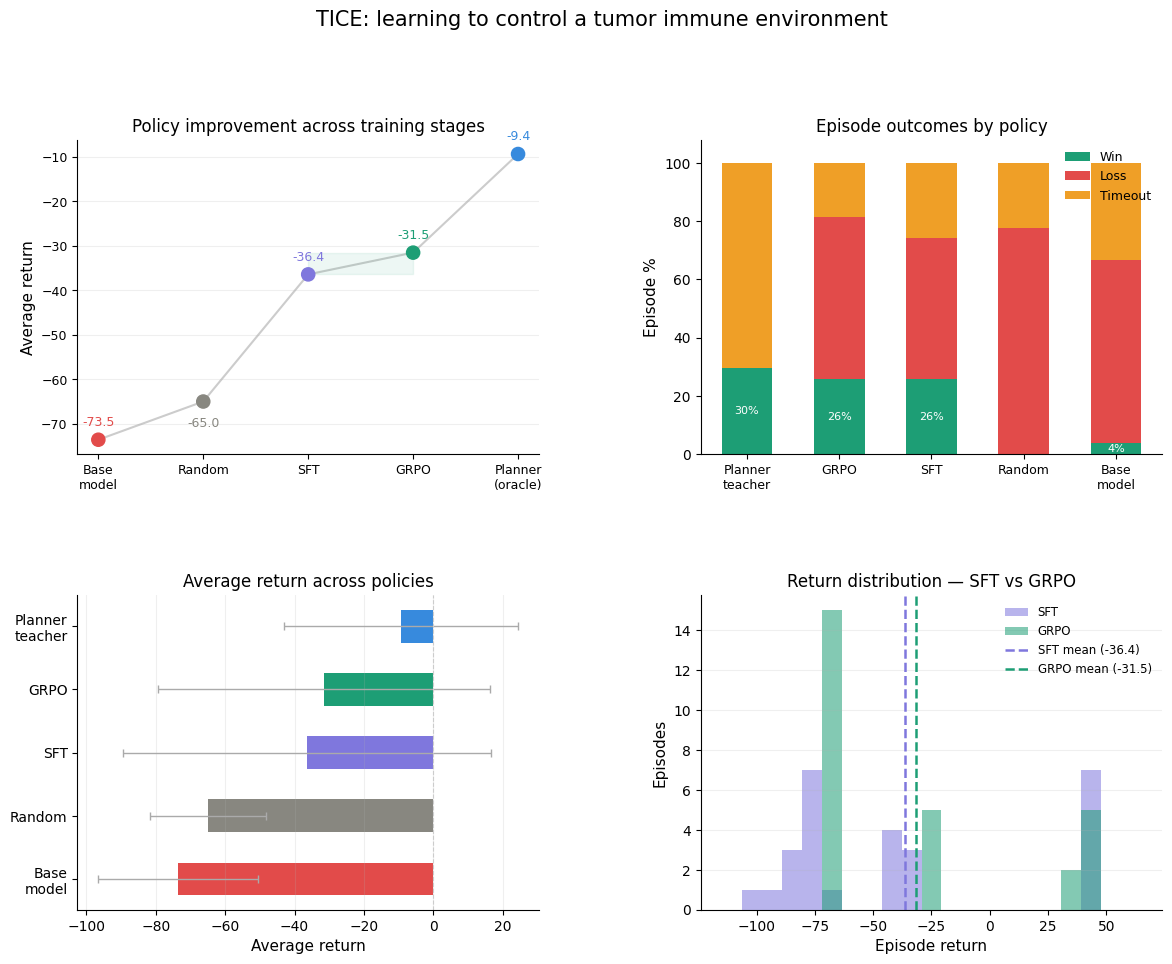

Saved to /content/final_save/tice_results_story.png


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

RESULTS_DIR = '/content/final_save'

base  = pd.read_csv(os.path.join(RESULTS_DIR, 'base_model_eval.csv'))
sft   = pd.read_csv(os.path.join(RESULTS_DIR, 'sft_model_eval.csv'))
grpo  = pd.read_csv(os.path.join(RESULTS_DIR, 'grpo_model_eval.csv'))
rand  = pd.read_csv(os.path.join(RESULTS_DIR, 'random_eval.csv')).head(27)
plan  = pd.read_csv(os.path.join(RESULTS_DIR, 'planner_eval.csv'))
sft_seeds = set(range(3000, 3027))
plan = plan[plan['seed'].isin(sft_seeds)].reset_index(drop=True)

for df, name in [(base,'base_model'),(sft,'sft_model'),(grpo,'grpo_model'),(rand,'random'),(plan,'planner_teacher')]:
    df['policy'] = name

all_df = pd.concat([base, sft, grpo, rand, plan], ignore_index=True)

POLICY_ORDER  = ['planner_teacher','grpo_model','sft_model','random','base_model']
POLICY_LABELS = ['Planner\nteacher','GRPO','SFT','Random','Base\nmodel']
COLORS = {'planner_teacher':'#378ADD','grpo_model':'#1D9E75','sft_model':'#7F77DD',
          'random':'#888780','base_model':'#E24B4A'}

summary = (
    all_df.groupby('policy').agg(
        avg_return=('return','mean'),
        std_return=('return','std'),
        win_rate=('won','mean'),
        loss_rate=('lost','mean'),
        timeout_rate=('timeout','mean'),
        avg_steps=('steps','mean'),
        avg_tumor=('final_tumor_size','mean'),
    ).loc[POLICY_ORDER]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TICE: learning to control a tumor immune environment',
             fontsize=15, fontweight='normal', y=1.01)
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# ── 1. Training progression — the core narrative ───────────────────────────
ax = axes[0, 0]
stages        = ['Base\nmodel', 'Random', 'SFT', 'GRPO', 'Planner\n(oracle)']
stage_keys    = ['base_model', 'random', 'sft_model', 'grpo_model', 'planner_teacher']
stage_returns = [summary.loc[p, 'avg_return'] for p in stage_keys]
stage_colors  = [COLORS[p] for p in stage_keys]

ax.plot(stages, stage_returns, color='#cccccc', linewidth=1.5, zorder=1)
ax.scatter(stages, stage_returns, color=stage_colors, s=90, zorder=2)
for i, (s, v, c) in enumerate(zip(stages, stage_returns, stage_colors)):
    offset = 10 if i not in [1] else -18
    ax.annotate(f'{v:.1f}', (i, v), textcoords='offset points',
                xytext=(0, offset), ha='center', fontsize=9, color=c)

ax.fill_between([2, 3], stage_returns[2], stage_returns[3],
                alpha=0.08, color='#1D9E75')
ax.set_ylabel('Average return', fontsize=11)
ax.set_title('Policy improvement across training stages', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)
ax.tick_params(labelsize=9)

# ── 2. Episode outcomes stacked bar ────────────────────────────────────────
ax = axes[0, 1]
x = np.arange(len(POLICY_ORDER))
win_vals     = [summary.loc[p, 'win_rate']     * 100 for p in POLICY_ORDER]
loss_vals    = [summary.loc[p, 'loss_rate']    * 100 for p in POLICY_ORDER]
timeout_vals = [summary.loc[p, 'timeout_rate'] * 100 for p in POLICY_ORDER]

b1 = ax.bar(x, win_vals,     color='#1D9E75', label='Win',     width=0.55)
b2 = ax.bar(x, loss_vals,    bottom=win_vals,
            color='#E24B4A', label='Loss',    width=0.55)
b3 = ax.bar(x, timeout_vals,
            bottom=[w + l for w, l in zip(win_vals, loss_vals)],
            color='#EF9F27', label='Timeout', width=0.55)

ax.set_xticks(x)
ax.set_xticklabels(POLICY_LABELS, fontsize=9)
ax.set_ylabel('Episode %', fontsize=11)
ax.set_title('Episode outcomes by policy', fontsize=12)
ax.set_ylim(0, 108)
ax.legend(fontsize=9, frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
for bar, val in zip(b1, win_vals):
    if val > 3:
        ax.text(bar.get_x() + bar.get_width() / 2, val / 2,
                f'{val:.0f}%', ha='center', va='center',
                fontsize=8, color='white')

# ── 3. Average return with error bars ──────────────────────────────────────
ax = axes[1, 0]
returns = summary['avg_return'].values
stds    = summary['std_return'].values
ax.barh(
    POLICY_LABELS[::-1], returns[::-1],
    xerr=stds[::-1],
    color=[COLORS[p] for p in POLICY_ORDER[::-1]],
    error_kw=dict(elinewidth=1, capsize=3, ecolor='#aaaaaa'),
    height=0.52
)
ax.axvline(0, color='#cccccc', linewidth=0.8, linestyle='--')
ax.set_xlabel('Average return', fontsize=11)
ax.set_title('Average return across policies', fontsize=12)
ax.tick_params(labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.2)

# ── 4. Return distribution SFT vs GRPO ─────────────────────────────────────
ax = axes[1, 1]
bins = np.linspace(-115, 65, 22)
ax.hist(sft['return'].values,  bins=bins, alpha=0.55, color='#7F77DD',
        label='SFT',  edgecolor='none')
ax.hist(grpo['return'].values, bins=bins, alpha=0.55, color='#1D9E75',
        label='GRPO', edgecolor='none')
ax.axvline(sft['return'].mean(),  color='#7F77DD', linewidth=1.8,
           linestyle='--', label=f'SFT mean ({sft["return"].mean():.1f})')
ax.axvline(grpo['return'].mean(), color='#1D9E75', linewidth=1.8,
           linestyle='--', label=f'GRPO mean ({grpo["return"].mean():.1f})')
ax.set_xlabel('Episode return', fontsize=11)
ax.set_ylabel('Episodes', fontsize=11)
ax.set_title('Return distribution — SFT vs GRPO', fontsize=12)
ax.legend(fontsize=8.5, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)

plt.savefig(os.path.join(RESULTS_DIR, 'tice_results_story.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved to', os.path.join(RESULTS_DIR, 'tice_results_story.png'))

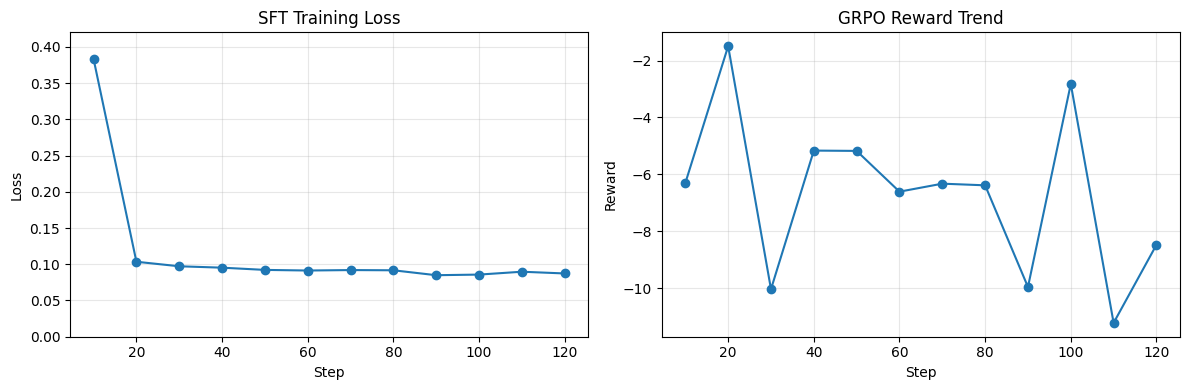

In [10]:
# --- SFT vs GRPO training visualization ---
# -- based on the training values above for SFT and GRPO ---

# ----- SFT -----
sft_steps = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
sft_loss  = [0.383113, 0.103451, 0.097203, 0.095267, 0.092200,
             0.091341, 0.091970, 0.091669, 0.084878, 0.085733,
             0.089680, 0.087289]

# ----- GRPO (reward only — NOT loss) -----
grpo_steps = sft_steps
grpo_reward = [-6.304865, -1.494823, -10.036504, -5.164798, -5.175924,
               -6.608683, -6.327601, -6.385519, -9.959246, -2.824726,
               -11.220613, -8.477210]

# ----- Plot -----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SFT Loss plot
axes[0].plot(sft_steps, sft_loss, marker='o')
axes[0].set_title('SFT Training Loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_ylim(0, 0.42)
axes[0].grid(alpha=0.3)

# GRPO Reward plot
axes[1].plot(grpo_steps, grpo_reward, marker='o')
axes[1].set_title('GRPO Reward Trend')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Reward')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
import pandas as pd
import numpy as np
import os

RESULTS_DIR = '/content/final_save'

base  = pd.read_csv(os.path.join(RESULTS_DIR, 'base_model_eval.csv'))
sft   = pd.read_csv(os.path.join(RESULTS_DIR, 'sft_model_eval.csv'))
grpo  = pd.read_csv(os.path.join(RESULTS_DIR, 'grpo_model_eval.csv'))
rand  = pd.read_csv(os.path.join(RESULTS_DIR, 'random_eval.csv')).head(27)
plan  = pd.read_csv(os.path.join(RESULTS_DIR, 'planner_eval.csv'))
sft_seeds = set(range(3000, 3027))
plan = plan[plan['seed'].isin(sft_seeds)].reset_index(drop=True)

for df, name in [(base,'base_model'),(sft,'sft_model'),(grpo,'grpo_model'),(rand,'random'),(plan,'planner_teacher')]:
    df['policy'] = name

all_df = pd.concat([base, sft, grpo, rand, plan], ignore_index=True)

POLICY_ORDER  = ['planner_teacher','grpo_model','sft_model','random','base_model']
POLICY_LABELS = {'planner_teacher':'Planner teacher','grpo_model':'GRPO model',
                 'sft_model':'SFT model','random':'Random','base_model':'Base model'}

summary = (
    all_df.groupby('policy').agg(
        n=('return','count'),
        avg_return=('return','mean'),
        std_return=('return','std'),
        win_rate=('won','mean'),
        loss_rate=('lost','mean'),
        timeout_rate=('timeout','mean'),
        avg_steps=('steps','mean'),
        avg_tumor=('final_tumor_size','mean'),
        avg_invalid=('invalid_action_rate','mean'),
    ).loc[POLICY_ORDER]
)

print('=' * 62)
print('TICE EVALUATION SUMMARY')
print('=' * 62)

for policy in POLICY_ORDER:
    r = summary.loc[policy]
    label = POLICY_LABELS[policy]
    print(f'\n{label}')
    print('-' * len(label))
    print(f'  Episodes          : {int(r.n)}')
    print(f'  Avg return        : {r.avg_return:.2f} ± {r.std_return:.2f}')
    print(f'  Win rate          : {r.win_rate*100:.1f}%')
    print(f'  Loss rate         : {r.loss_rate*100:.1f}%')
    print(f'  Timeout rate      : {r.timeout_rate*100:.1f}%')
    print(f'  Avg steps         : {r.avg_steps:.1f}')
    print(f'  Avg final tumor   : {r.avg_tumor:.3f}')
    print(f'  Avg invalid rate  : {r.avg_invalid:.3f}')

print('\n' + '=' * 62)
print('PAIRWISE COMPARISONS')
print('=' * 62)

pairs = [
    ('grpo_model', 'sft_model',  'GRPO vs SFT'),
    ('sft_model',  'base_model', 'SFT vs Base'),
    ('grpo_model', 'base_model', 'GRPO vs Base'),
    ('grpo_model', 'random',     'GRPO vs Random'),
]

for p1, p2, label in pairs:
    r1, r2 = summary.loc[p1], summary.loc[p2]
    ret_delta     = r1.avg_return    - r2.avg_return
    win_delta     = (r1.win_rate     - r2.win_rate)    * 100
    timeout_delta = (r1.timeout_rate - r2.timeout_rate) * 100
    tumor_delta   = r1.avg_tumor     - r2.avg_tumor
    print(f'\n  {label}')
    print(f'    Return delta    : {ret_delta:+.2f}')
    print(f'    Win rate delta  : {win_delta:+.1f}pp')
    print(f'    Timeout delta   : {timeout_delta:+.1f}pp')
    print(f'    Tumor delta     : {tumor_delta:+.3f}')

print('\n' + '=' * 62)
print('WINS BY ARCHETYPE & DIFFICULTY')
print('=' * 62)

for policy in ['planner_teacher', 'grpo_model', 'sft_model', 'base_model']:
    df = all_df[(all_df['policy'] == policy) & (all_df['won'] == 1)]
    label = POLICY_LABELS[policy]
    print(f'\n  {label} ({len(df)} wins)')
    if len(df) == 0:
        print('    None')
        continue
    breakdown = df.groupby(['archetype', 'difficulty']).size().reset_index(name='wins')
    for _, row in breakdown.iterrows():
        print(f'    {row.archetype:20s} {row.difficulty:8s} → {int(row.wins)} win(s)')

print('\n' + '=' * 62)

TICE EVALUATION SUMMARY

Planner teacher
---------------
  Episodes          : 27
  Avg return        : -9.37 ± 33.73
  Win rate          : 29.6%
  Loss rate         : 0.0%
  Timeout rate      : 70.4%
  Avg steps         : 41.3
  Avg final tumor   : 0.612
  Avg invalid rate  : 0.000

GRPO model
----------
  Episodes          : 27
  Avg return        : -31.52 ± 47.83
  Win rate          : 25.9%
  Loss rate         : 55.6%
  Timeout rate      : 18.5%
  Avg steps         : 26.8
  Avg final tumor   : 0.676
  Avg invalid rate  : 0.000

SFT model
---------
  Episodes          : 27
  Avg return        : -36.40 ± 52.97
  Win rate          : 25.9%
  Loss rate         : 48.1%
  Timeout rate      : 25.9%
  Avg steps         : 28.9
  Avg final tumor   : 0.630
  Avg invalid rate  : 0.000

Random
------
  Episodes          : 27
  Avg return        : -64.96 ± 16.78
  Win rate          : 0.0%
  Loss rate         : 77.8%
  Timeout rate      : 22.2%
  Avg steps         : 29.8
  Avg final tumor   : 0.927